In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 36.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# Load the dataset
df_train = pd.read_csv('FP data train.csv')

# Names of columns with functional group countings
fg_cols = ['dnAB', 'dnCCDB2', 'dnQC', 'g-CH3', 'g-CH2-(linear)', 'g-O-(ring)', 'g>C=Oring', 'g-COO-(linear) ester', 'g-CH- (linear)',
           'g-CH=(lineal)', 'g-CH= (ring)', 'g-CH- (ring)', 'g-CH2-(ring)', 'dnOHprim',
           'dnOHsec', 'dnOHter']

# Define the columns for the new DataFrame, including Modularity and Flash point exp. (K)
selected_columns = fg_cols + ['Modularity', 'FP exp. (K)']

# Create FP_df2 with the selected columns
FP_df2 = df_train[selected_columns].copy()

FP_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422 entries, 0 to 421
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   dnAB                  422 non-null    int64  
 1   dnCCDB2               422 non-null    int64  
 2   dnQC                  422 non-null    int64  
 3   g-CH3                 422 non-null    int64  
 4   g-CH2-(linear)        422 non-null    int64  
 5   g-O-(ring)            422 non-null    int64  
 6   g>C=Oring             422 non-null    int64  
 7   g-COO-(linear) ester  422 non-null    int64  
 8   g-CH- (linear)        422 non-null    int64  
 9   g-CH=(lineal)         422 non-null    int64  
 10  g-CH= (ring)          422 non-null    int64  
 11  g-CH- (ring)          422 non-null    int64  
 12  g-CH2-(ring)          422 non-null    int64  
 13  dnOHprim              422 non-null    int64  
 14  dnOHsec               422 non-null    int64  
 15  dnOHter               4

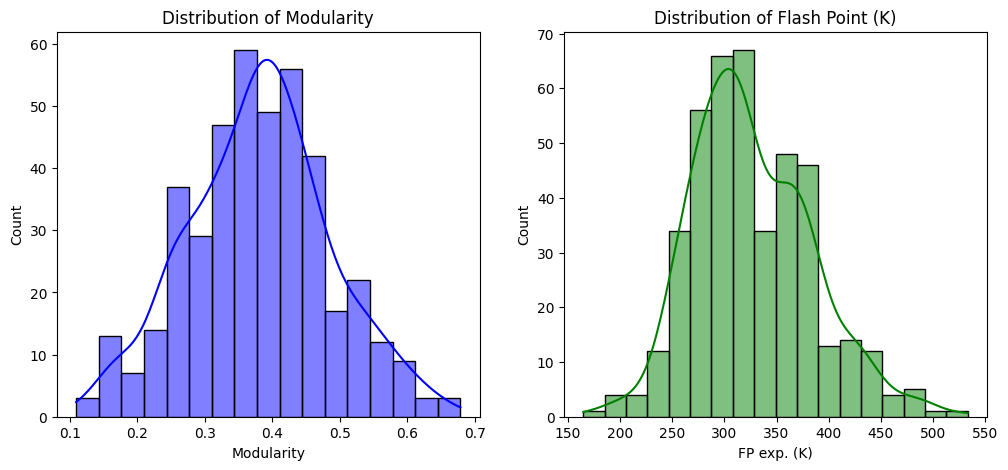

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(FP_df2['Modularity'], kde=True, color='blue')
plt.title('Distribution of Modularity')
plt.subplot(1, 2, 2)
sns.histplot(FP_df2['FP exp. (K)'], kde=True, color='green')
plt.title('Distribution of Flash Point (K)')
plt.savefig('distribution_plots.png')

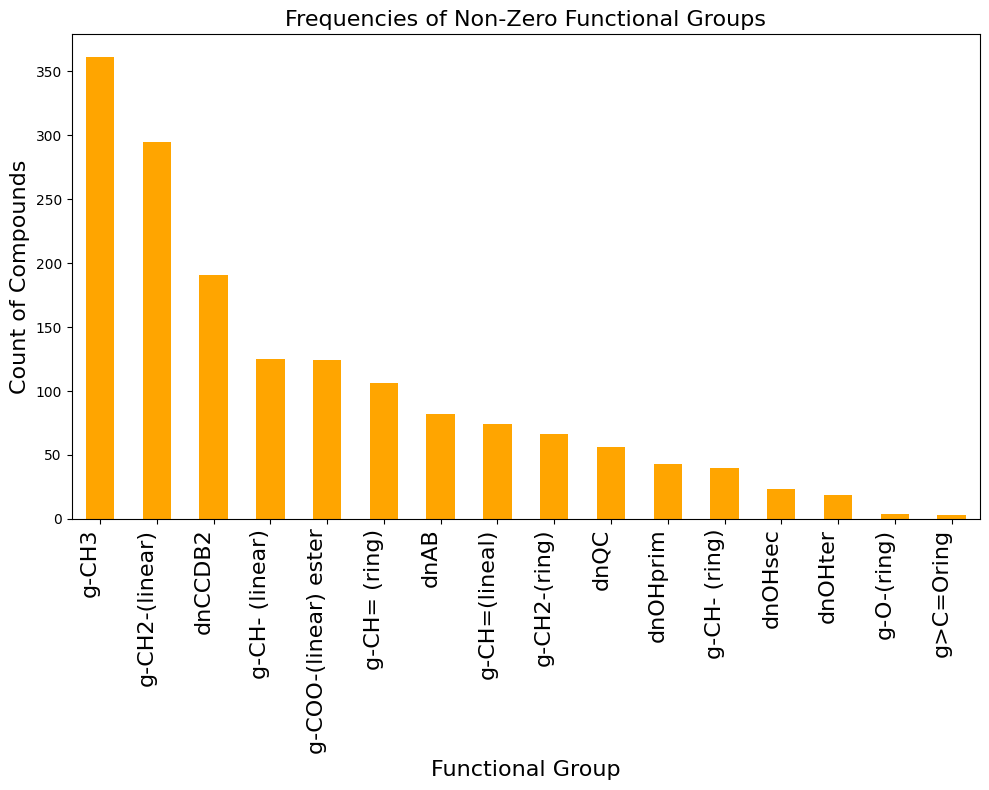

In [ ]:
fg_counts = (FP_df2[fg_cols] != 0).sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
fg_counts.plot(kind='bar', color='orange')
plt.title('Frequencies of Non-Zero Functional Groups', fontsize=16)
plt.ylabel('Count of Compounds', fontsize=16)
plt.xlabel('Functional Group', fontsize=16)
plt.xticks(rotation=90, ha='right', fontsize=16) # Rotate labels for better readability
plt.tight_layout()
plt.savefig('fg_freq.png')

In [ ]:
display(FP_df2[['Modularity', 'FP exp. (K)']].describe())

,Modularity,FP exp. (K)
count,422.000000,422.000000
mean,0.380849,326.780521
std,0.105020,57.428204
min,0.109375,165.000000
25%,0.315748,286.000000
50%,0.377551,319.000000
75%,0.445000,366.150000
max,0.678504,533.150000


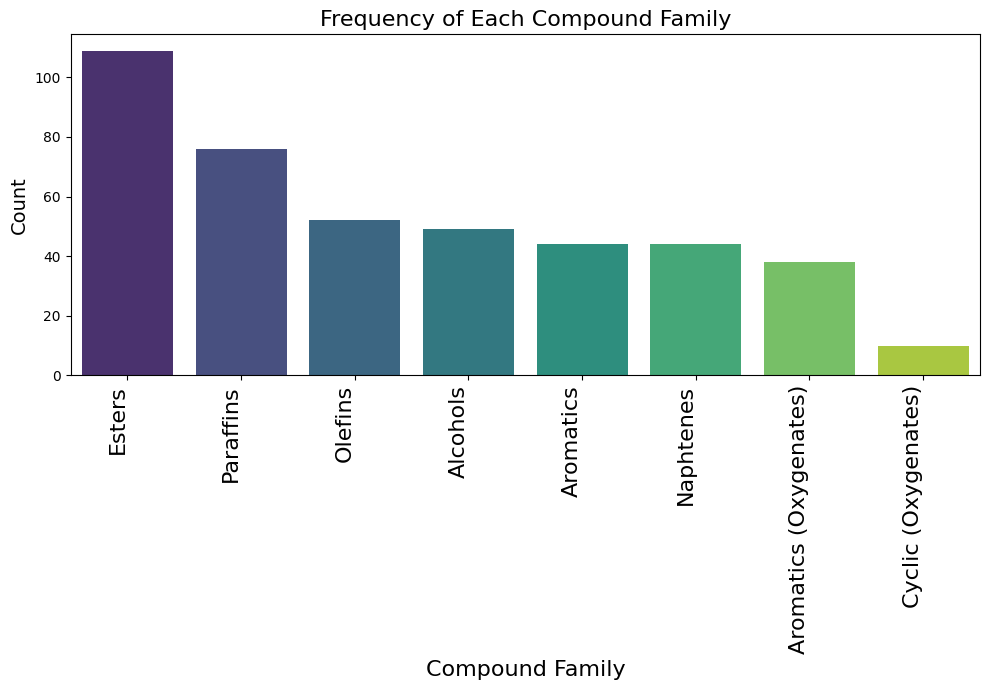

In [ ]:
family_counts = df_train['Family'].value_counts()

plt.figure(figsize=(10, 7))
sns.barplot(x=family_counts.index, y=family_counts.values, hue=family_counts.index, palette='viridis', legend=False)
plt.title('Frequency of Each Compound Family', fontsize=16)
plt.xlabel('Compound Family', fontsize=16)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=16)
plt.tight_layout()
plt.savefig('compound_family_freq.png')
plt.show()

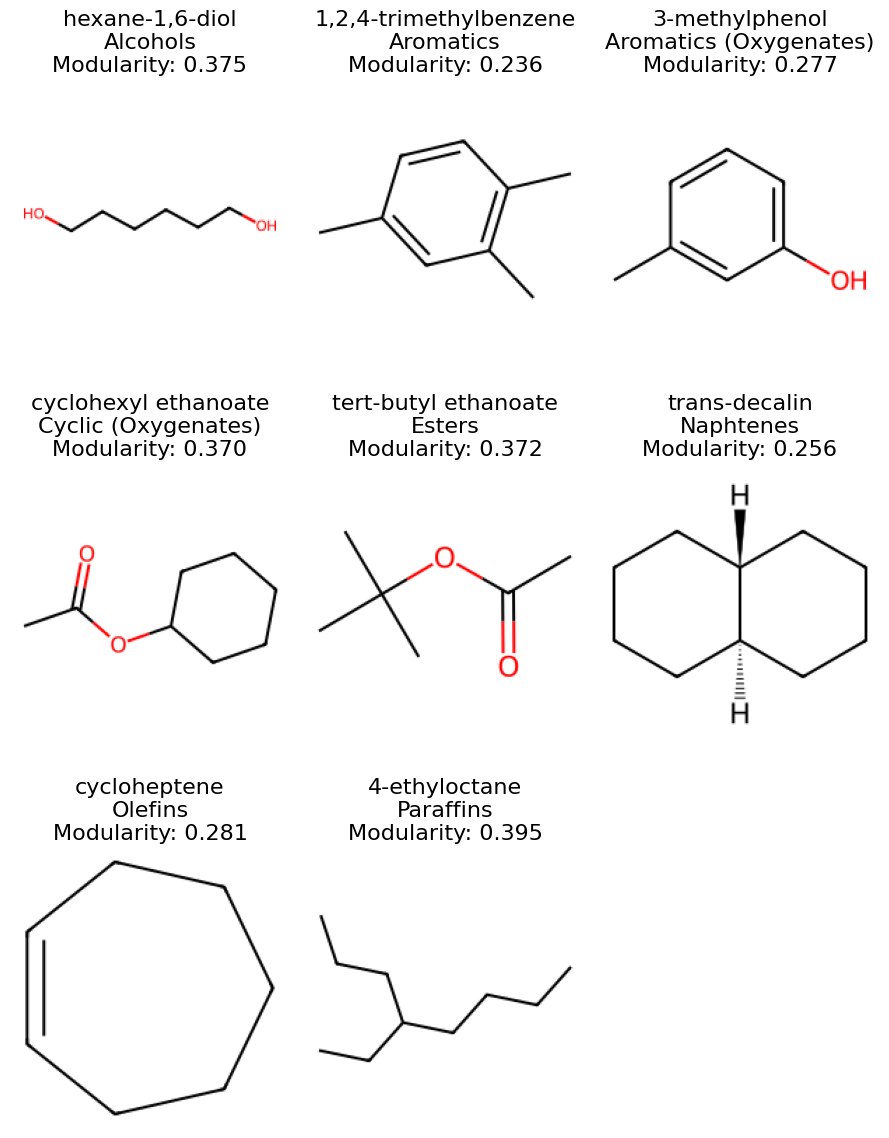

In [ ]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

# Function to get the number of atoms from a SMILES string
def get_num_atoms(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return mol.GetNumAtoms()
    return None

# Calculate number of atoms and add it as a new column to FP_df2
df_train_copy = df_train.copy()
df_train_copy['NumAtoms'] = df_train_copy['Smiles'].apply(get_num_atoms)

# Filter compounds with a maximum of 10 atoms
filtered_atoms = df_train_copy[df_train_copy['NumAtoms'] <= 10].dropna(subset=['NumAtoms'])

# Select one RANDOM representative compound for each family from the filtered set
# Using .sample(1) to get one random row from each group
representative_compounds = filtered_atoms.groupby('Family').sample(n=1, random_state=None) # Set random_state for reproducibility if needed

num_families = len(representative_compounds)
# Determine grid size for subplots
num_cols = 3
num_rows = (num_families + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 3, num_rows * 4))

for i, (idx, row) in enumerate(representative_compounds.iterrows()):
    smiles = row['Smiles']
    name = row['Name']
    modularity = row['Modularity']
    family = row['Family']

    # Insert a newline character if the name is too long
    if len(name) > 20: # You can adjust this threshold as needed
        name = name.replace(' ', '\n', 1) # Replace the first space with a newline

    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        img = Draw.MolToImage(mol, size=(200, 200)) # Decreased image size

        ax = plt.subplot(num_rows, num_cols, i + 1)
        ax.imshow(img)
        # Increased font size in the title to include name, family, and modularity
        ax.set_title(f"{name}\n{family}\nModularity: {modularity:.3f}", fontsize=16) # Increased font size
        ax.axis('off')
    else:
        print(f"Could not generate molecule for SMILES: {smiles}")

plt.tight_layout()
plt.savefig('representative_molecular_structures_random_filtered_by_atoms.png')
plt.show()

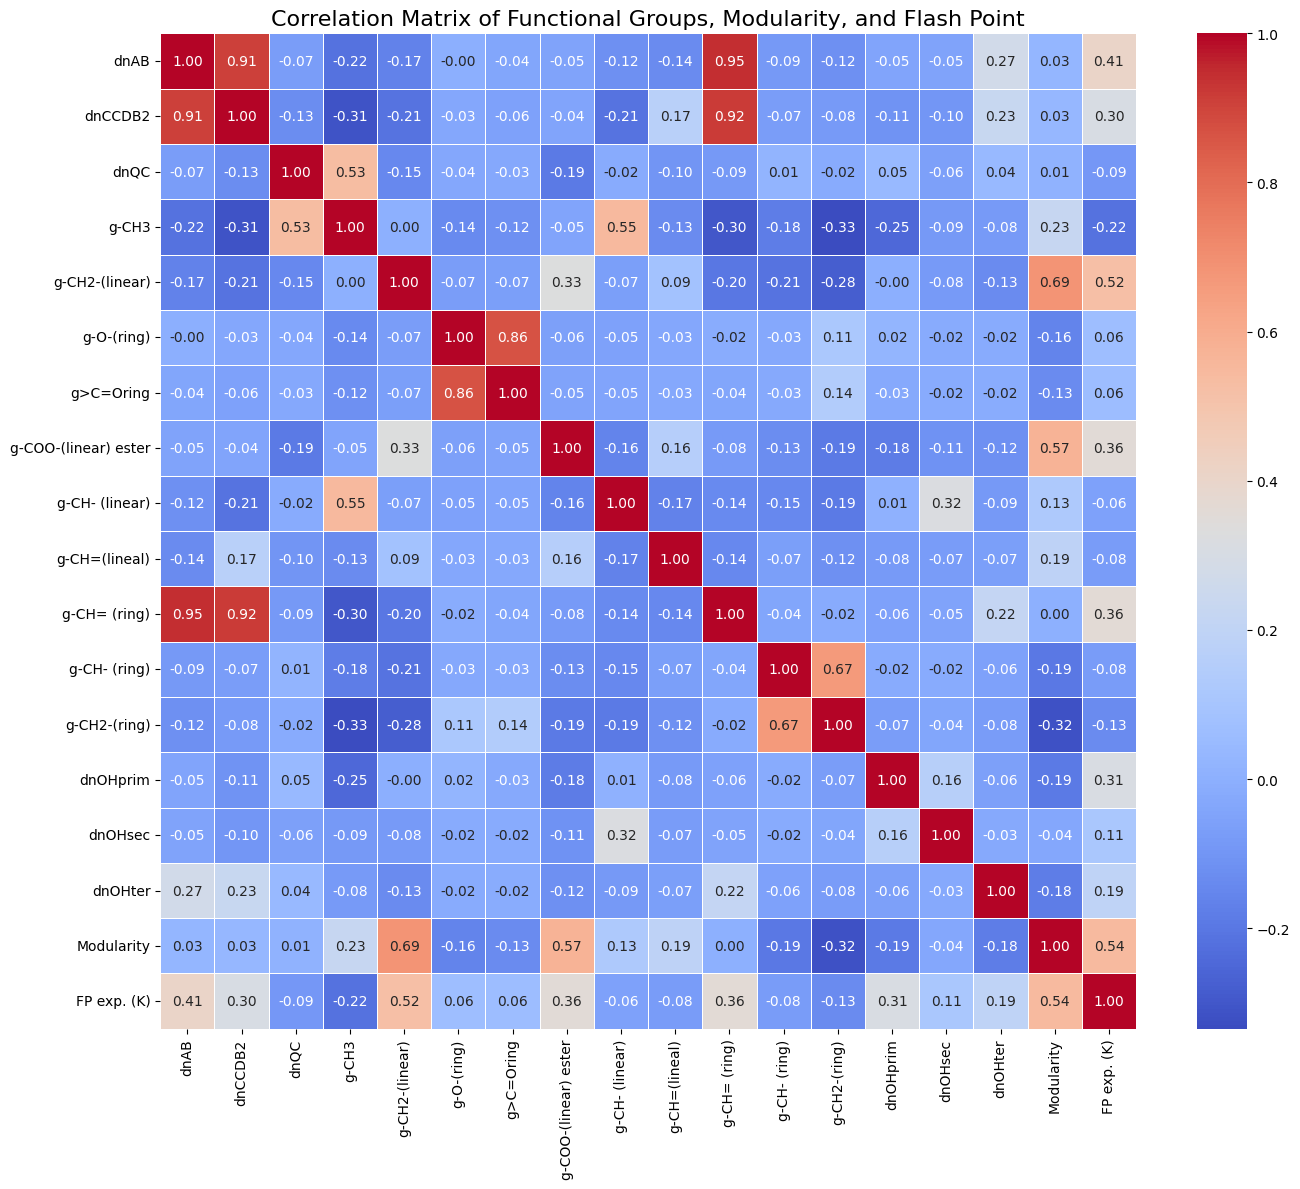

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the relevant numerical columns in FP_df2
correlation_matrix = FP_df2.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Functional Groups, Modularity, and Flash Point', fontsize=16)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

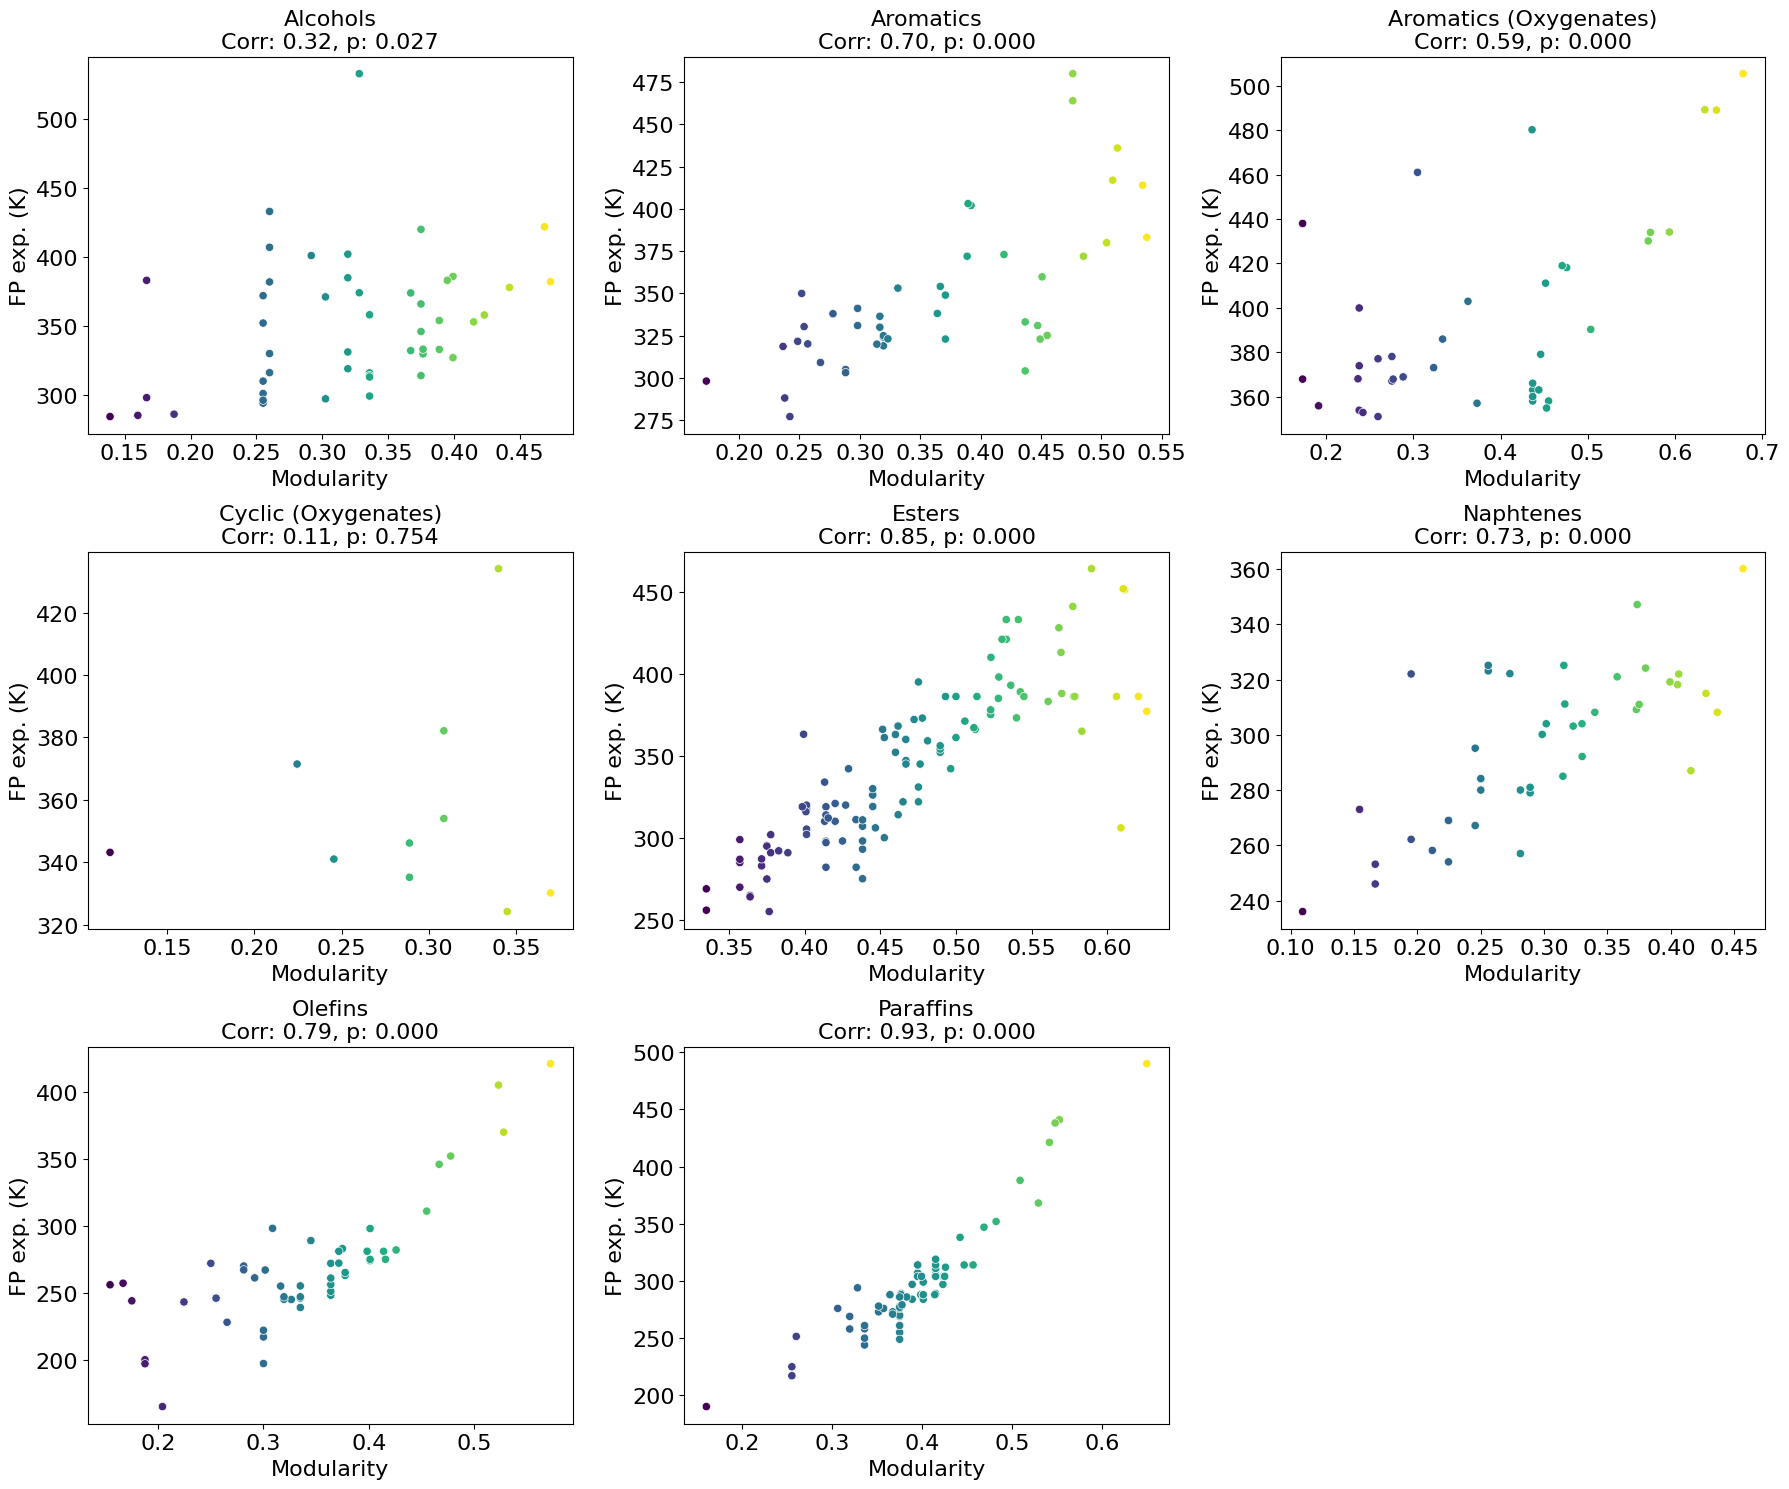

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Get unique families
unqiue_families = df_train['Family'].unique()
num_families = len(unqiue_families)

# Determine grid size for subplots
num_cols = 3 # You can adjust this number
num_rows = (num_families + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, family in enumerate(unqiue_families):
    ax = plt.subplot(num_rows, num_cols, i + 1)

    # Filter data for the current family
    family_df = df_train[df_train['Family'] == family]

    # Calculate Pearson correlation and p-value
    if len(family_df) > 1:
        correlation, p_value = pearsonr(family_df['Modularity'], family_df['FP exp. (K)'])
    else:
        correlation, p_value = float('nan'), float('nan') # Cannot calculate with one or zero data points

    # Create scatter plot
    sns.scatterplot(x='Modularity', y='FP exp. (K)', data=family_df, ax=ax, hue='Modularity', palette='viridis', legend=False)

    # Set title with correlation and p-value
    title_str = f"{family}\nCorr: {correlation:.2f}, p: {p_value:.3f}"
    ax.set_title(title_str, fontsize=16)
    ax.set_xlabel('Modularity', fontsize=16)
    ax.set_ylabel('FP exp. (K)', fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig('modularity_flashpoint_correlation_by_family.png')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_train[fg_cols + ['Modularity']].values
y = df_train[['FP exp. (K)']].values

# The data splitting and scaling logic will be handled within the model training
# to allow for multiple runs with different random splits for hyperparameter tuning.

In [ ]:
# initial test for scaler and activation function
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

best_mse = float('inf')
best_params = None
best_model = None
results = []
num_runs = 10
layer_size=10

for run_number in range(num_runs): # Outer loop for multiple runs
    print(f"--- Run {run_number + 1}/{num_runs} ---")

    # Perform train-test split once for comparability setting random state
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # random_state for reproducibility per run

    #Loop for scaler options
    for scaler in ["MinMaxScaler", "StandardScaler"]:
        #Set scaler
        if scaler == "MinMaxScaler":
            X_scaler = MinMaxScaler()
            y_scaler = MinMaxScaler()
        else:
            X_scaler = StandardScaler()
            y_scaler = StandardScaler()

        #Apply scaler to train set and transform test set
        X_train_scaled = X_scaler.fit_transform(X_train)
        y_train_scaled = y_scaler.fit_transform(y_train)
        X_test_scaled = X_scaler.transform(X_test)
        y_test_scaled = y_scaler.transform(y_test)

        #Loop for activation function options
        for activation_function in ["sigmoid", "relu", "tanh"]:
            model = Sequential([
                Input(shape=(X_train_scaled.shape[1],)),
                Dense(layer_size, activation=activation_function), #Change here to try different activation function "sigmoid", "relu", etc.
                Dense(1, activation='linear')
            ])

            model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
            model.fit(X_train_scaled, y_train_scaled, epochs=300, batch_size=64, verbose=0)

            # Train predictions
            y_train_pred_scaled = model(X_train_scaled, training=False).numpy()
            y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)
            mse_train = mean_squared_error(y_train, y_train_pred)
            r2_train = r2_score(y_train, y_train_pred)

            # Test predictions
            y_test_pred_scaled = model(X_test_scaled, training=False).numpy()
            y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)
            mse_test = mean_squared_error(y_test, y_test_pred)
            r2_test = r2_score(y_test, y_test_pred)

            results.append({
                'scaler': scaler,
                'activation_function': activation_function,
                'run_number': run_number + 1,
                'mse_train': mse_train,
                'r2_train': r2_train,
                'mse_test': mse_test,
                'r2_test': r2_test
            })

            if mse_test < best_mse:
                best_mse = mse_test
                best_params = {'layer_size': layer_size, 'run': run_number + 1}
                best_model = model
                final_X_test_scaled = X_test_scaled # Store the scaled test set from the best model's run
                final_y_test = y_test # Store the actual y_test from the best model's run
results_df = pd.DataFrame(results)
display(results_df)

--- Run 1/10 ---
--- Run 2/10 ---
--- Run 3/10 ---
--- Run 4/10 ---
--- Run 5/10 ---
--- Run 6/10 ---
--- Run 7/10 ---
--- Run 8/10 ---
--- Run 9/10 ---
--- Run 10/10 ---


,scaler,activation_function,run_number,mse_train,r2_train,mse_test,r2_test
0,MinMaxScaler,sigmoid,1,386.251111,0.883278,631.618374,0.800445
1,MinMaxScaler,relu,1,298.474632,0.909803,679.683295,0.785259
2,MinMaxScaler,tanh,1,304.220580,0.908067,657.729740,0.792195
3,StandardScaler,sigmoid,1,309.350246,0.906517,345.416208,0.890868
4,StandardScaler,relu,1,196.222732,0.940703,496.966720,0.842987
5,StandardScaler,tanh,1,185.562314,0.943925,309.225796,0.902302
6,MinMaxScaler,sigmoid,2,649.525518,0.803719,785.998046,0.751669
7,MinMaxScaler,relu,2,277.945359,0.916007,808.400844,0.744591
8,MinMaxScaler,tanh,2,332.572370,0.899499,417.901096,0.867967
9,StandardScaler,sigmoid,2,265.537550,0.919757,326.289353,0.896911


In [ ]:
display(results_df.groupby(['scaler','activation_function'])[['mse_train', 'r2_train', 'mse_test', 'r2_test']].agg(['mean', 'std']))

mse_train             r2_train            \
                                          mean        std      mean       std   
scaler         activation_function                                              
MinMaxScaler   relu                 296.276281  34.515136  0.910468  0.010430   
               sigmoid              451.403563  87.593921  0.863590  0.026470   
               tanh                 338.843009  39.504791  0.897604  0.011938   
StandardScaler relu                 206.737283  28.118852  0.937526  0.008497   
               sigmoid              285.881200  18.668368  0.913609  0.005641   
               tanh                 186.859534  13.269836  0.943533  0.004010   

                                      mse_test               r2_test            
                                          mean         std      mean       std  
scaler         activation_function                                              
MinMaxScaler   relu                 698.466088  172.022627  0.779325  0.054349  
               sigmoid              658.688622   51.948880  0.791892  0.016413  
               tanh                 542.489948   87.943259  0.828604  0.027785  
StandardScaler relu                 549.892563  231.794510  0.826265  0.073234  
               sigmoid              336.689267   25.548600  0.893625  0.008072  
               tanh                 275.162056   35.766006  0.913064  0.011300

In [ ]:
# TRAINING WITH 5-K CROSS-VALIDATION, STANDARD SCALER

best_mse_overall = float('inf') # Track the best MSE across all folds and parameter combinations
best_params_cv = None
best_model_cv = None
best_X_scaler_cv = None # Store the scaler from the best performing fold
best_y_scaler_cv = None # Store the scaler from the best performing fold
results_cv = [] # Renamed
lr=0.01
n_splits = 5 # 5-fold cross-validation
skf = KFold(n_splits=n_splits, shuffle=True, random_state=42) # Initialize K-Fold

# Loop through each fold for cross-validation
for fold, (train_index, val_index) in enumerate(skf.split(X, y)): # Use KFold with X and y
    print(f"--- Fold {fold + 1}/{n_splits} ---")

    X_train_fold, X_val_fold = X[train_index], X[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]

    # Initialize and fit scalers for the current fold's split
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_train_scaled = X_scaler.fit_transform(X_train_fold)
    y_train_scaled = y_scaler.fit_transform(y_train_fold)
    X_val_scaled = X_scaler.transform(X_val_fold)
    y_val_scaled = y_scaler.transform(y_val_fold) # Scaled y_val for val_loss

    for layer_size in [10, 12, 14, 16, 32, 64, 128]:
            model = Sequential([
                Input(shape=(X_train_scaled.shape[1],)),
                Dense(layer_size, activation='tanh'),
                Dense(1, activation='linear')
            ])

            model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
            # Fit and test with validation data from the current fold
            model.fit(X_train_scaled, y_train_scaled,
                      epochs=300,
                      batch_size=64,
                      verbose=0,
                      validation_data=(X_val_scaled, y_val_scaled))

            # Train predictions
            y_train_pred_scaled = model.predict(X_train_scaled, verbose=0)
            y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled).flatten()
            mse_train = mean_squared_error(y_train_fold, y_train_pred)
            r2_train = r2_score(y_train_fold, y_train_pred)

            # Validation predictions
            y_val_pred_scaled = model.predict(X_val_scaled, verbose=0)
            y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled).flatten()
            mse_val = mean_squared_error(y_val_fold, y_val_pred)
            r2_val = r2_score(y_val_fold, y_val_pred)

            results_cv.append({
                'layer_size': layer_size,
                'fold': fold + 1, # Use fold number instead of run_number
                'mse_train': mse_train,
                'r2_train': r2_train,
                'mse_val': mse_val, # Changed from mse_test
                'r2_val': r2_val # Changed from r2_test
            })

            # Track overall best model based on validation MSE
            if mse_val < best_mse_overall:
                best_mse_overall = mse_val
                best_params_cv = {'layer_size': layer_size, 'fold': fold + 1, 'lr': lr}
                best_model_cv = model
                best_X_scaler_cv = X_scaler
                best_y_scaler_cv = y_scaler
                # Store the validation set data corresponding to the best model
                final_X_test_scaled_cv = X_val_scaled # This will serve as the "test set" for the best model from CV
                final_y_test_cv = y_val_fold # Actual y values for this best model's validation set

results_cv_df = pd.DataFrame(results_cv)
print(f"\nBest model (from CV): {best_params_cv} with MSE_val: {best_mse_overall:.4f}")
display(results_cv_df.groupby('layer_size')[['mse_train', 'r2_train', 'mse_val', 'r2_val']].agg(['mean', 'std']))

--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---

Best model (from CV): {'layer_size': 128, 'fold': 1, 'lr': 0.01} with MSE_val: 183.7523


mse_train             r2_train               mse_val             \
                 mean        std      mean       std        mean        std   
layer_size                                                                    
10          76.026530   5.546612  0.976858  0.001845  318.239408  53.705685   
12          69.262622   8.386727  0.978855  0.003242  320.708752  32.409137   
14          70.772910  11.844282  0.978496  0.003357  276.197424  46.383819   
16          64.912112   9.177249  0.980223  0.003037  371.670380  74.282022   
32          50.973153   4.019428  0.984451  0.001764  300.624068  63.855297   
64          62.615591  19.243306  0.980929  0.005852  346.040341  73.937571   
128         65.746899  14.934692  0.979944  0.004751  313.560758  82.419918   

              r2_val            
                mean       std  
layer_size                      
10          0.900570  0.023407  
12          0.900319  0.014911  
14          0.913362  0.022345  
16          0.885257  0.022164  
32          0.906487  0.022641  
64          0.892606  0.024538  
128         0.902938  0.026009

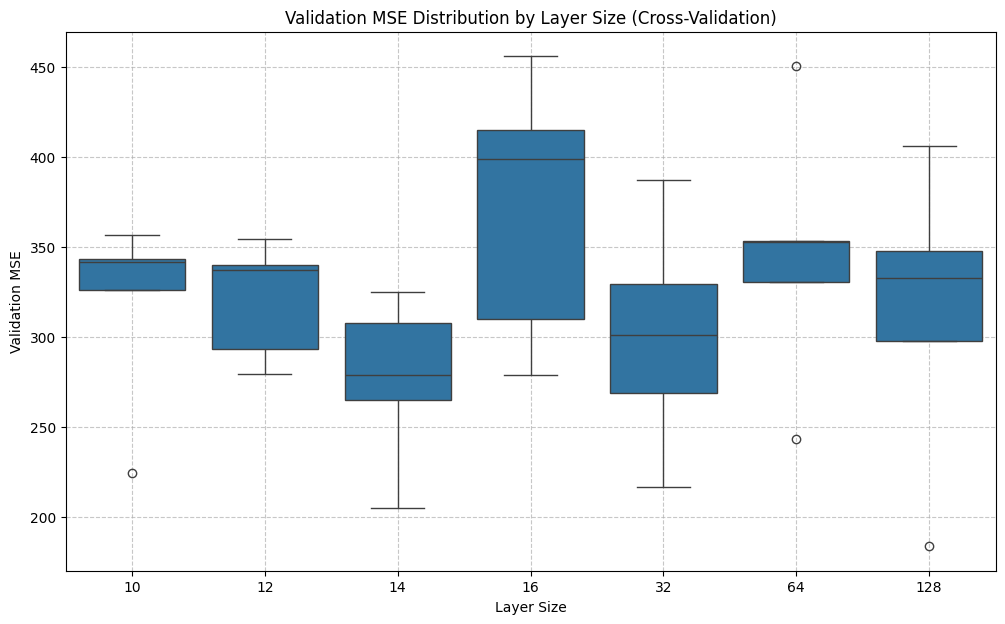

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(x='layer_size', y='mse_val', data=results_cv_df)
plt.title('Validation MSE Distribution by Layer Size (Cross-Validation)')
plt.xlabel('Layer Size')
plt.ylabel('Validation MSE')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
lowest_mse_val_for_layer_14 = results_cv_df[results_cv_df['layer_size'] == 14].nsmallest(1, 'mse_val')
display(lowest_mse_val_for_layer_14)

,layer_size,fold,mse_train,r2_train,mse_val,r2_val
2,14,1,79.558363,0.975958,204.774625,0.935303


In [ ]:
# Finding learning rate, with HN=14, standard scaler, tanh, 10-k CV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold


best_mse_overall = float('inf')
best_params_cv = None
best_model_cv = None
best_X_scaler_cv = None
best_y_scaler_cv = None
results_cv_lr = []

layer_size = 14
n_splits = 10
n_runs = 10  # Explicitly defined total repetitions

# Outer loop for multiple repetitions
for run_number in range(n_runs):
    print(f"\n--- Repetition Run {run_number + 1}/{n_runs} ---")

    # FIXED: Re-initializing KFold INSIDE with a changing seed ensures unique data splits every run
    skf = KFold(n_splits=n_splits, shuffle=True, random_state=42 + run_number)

    for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
        print(f"  --- Fold {fold + 1}/{n_splits} ---")

        X_train_fold, X_val_fold = X[train_index], X[val_index]
        y_train_fold, y_val_fold = y[train_index], y[val_index]

        # Initialize and fit scalers for the current fold's split
        X_scaler = StandardScaler()
        y_scaler = StandardScaler()

        X_train_scaled = X_scaler.fit_transform(X_train_fold)
        # Note: Ensure y is reshaped to 2D (-1, 1) if StandardScaler complains
        y_train_scaled = y_scaler.fit_transform(y_train_fold.reshape(-1, 1) if hasattr(y_train_fold, 'reshape') else y_train_fold)
        X_val_scaled = X_scaler.transform(X_val_fold)
        y_val_scaled = y_scaler.transform(y_val_fold.reshape(-1, 1) if hasattr(y_val_fold, 'reshape') else y_val_fold)

        for lr in [0.001, 0.01, 0.05, 0.1]:
            print(f"    --- Learning Rate: {lr} ---")
            model = Sequential([
                Input(shape=(X_train_scaled.shape[1],)),
                Dense(layer_size, activation='tanh'),
                Dense(1, activation='linear')
            ])

            model.compile(optimizer=Adam(learning_rate=lr), loss='mse')

            # FIXED: Properly nested inside the 'lr' loop
            model.fit(X_train_scaled, y_train_scaled,
                      epochs=300,
                      batch_size=64,
                      verbose=0,
                      validation_data=(X_val_scaled, y_val_scaled))

            # Train predictions
            y_train_pred_scaled = model.predict(X_train_scaled, verbose=0)
            y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled).flatten()
            mse_train = mean_squared_error(y_train_fold, y_train_pred)
            r2_train = r2_score(y_train_fold, y_train_pred)

            # Validation predictions
            y_val_pred_scaled = model.predict(X_val_scaled, verbose=0)
            y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled).flatten()
            mse_val = mean_squared_error(y_val_fold, y_val_pred)
            r2_val = r2_score(y_val_fold, y_val_pred)

            results_cv_lr.append({
                'run_repetition': run_number + 1,
                'fold': fold + 1,
                'lr': lr,
                'mse_train': mse_train,
                'r2_train': r2_train,
                'mse_val': mse_val,
                'r2_val': r2_val
            })

            # Track overall best model based on validation MSE
            if mse_val < best_mse_overall:
                best_mse_overall = mse_val
                best_params_cv = {'learning_rate': lr, 'run': run_number + 1, 'fold': fold + 1}
                best_model_cv = model
                best_X_scaler_cv = X_scaler
                best_y_scaler_cv = y_scaler
                final_X_test_scaled_cv = X_val_scaled
                final_y_test_cv = y_val_fold

print(f"\nBest model (from CV): {best_params_cv} with MSE: {best_mse_overall:.4f}")
results_cv_df_lr = pd.DataFrame(results_cv_lr)
display(results_cv_df_lr.groupby('lr')[['mse_train', 'r2_train', 'mse_val', 'r2_val']].agg(['mean', 'std']))


--- Repetition Run 1/10 ---
  --- Fold 1/10 ---
    --- Learning Rate: 0.001 ---
    --- Learning Rate: 0.01 ---
    --- Learning Rate: 0.05 ---
    --- Learning Rate: 0.1 ---
  --- Fold 2/10 ---
    --- Learning Rate: 0.001 ---
    --- Learning Rate: 0.01 ---
    --- Learning Rate: 0.05 ---
    --- Learning Rate: 0.1 ---
  --- Fold 3/10 ---
    --- Learning Rate: 0.001 ---
    --- Learning Rate: 0.01 ---
    --- Learning Rate: 0.05 ---
    --- Learning Rate: 0.1 ---
  --- Fold 4/10 ---
    --- Learning Rate: 0.001 ---
    --- Learning Rate: 0.01 ---
    --- Learning Rate: 0.05 ---
    --- Learning Rate: 0.1 ---
  --- Fold 5/10 ---
    --- Learning Rate: 0.001 ---
    --- Learning Rate: 0.01 ---
    --- Learning Rate: 0.05 ---
    --- Learning Rate: 0.1 ---
  --- Fold 6/10 ---
    --- Learning Rate: 0.001 ---
    --- Learning Rate: 0.01 ---
    --- Learning Rate: 0.05 ---
    --- Learning Rate: 0.1 ---
  --- Fold 7/10 ---
    --- Learning Rate: 0.001 ---
    --- Learning Rate: 0.01 --

mse_train             r2_train               mse_val              \
             mean        std      mean       std        mean         std   
lr                                                                         
0.001  150.306996  15.831705  0.954303  0.004661  323.772817  142.108372   
0.010   64.885440   6.404530  0.980266  0.001948  358.524888  173.328819   
0.050   68.442524  13.697362  0.979198  0.004067  388.369984  156.716356   
0.100   93.445427  33.625818  0.971541  0.010452  452.449377  195.990628   

         r2_val            
           mean       std  
lr                         
0.001  0.897903  0.041342  
0.010  0.887777  0.046743  
0.050  0.877324  0.045963  
0.100  0.857557  0.057215

In [ ]:
best_model_cv.save('best_flash_point_model_cv.keras')
print("Best model from cross-validation saved to 'best_flash_point_model_cv.keras'")

Best model from cross-validation saved to 'best_flash_point_model_cv.keras'


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Get unique families from the combined results DataFrame
unique_families = combined_results_df['Family'].unique()

family_metrics = []

for family in unique_families:
    # Filter data for the current family
    family_df = combined_results_df[combined_results_df['Family'] == family]

    # Separate into train and test sets for the current family
    train_family_df = family_df[family_df['Dataset_Type'] == 'Train Set']
    test_family_df = family_df[family_df['Dataset_Type'] == 'Test Set']

    # Calculate metrics for the Train Set (if data exists)
    if not train_family_df.empty:
        mse_train = mean_squared_error(train_family_df['Actual_Flash_Point_K'], train_family_df['Predicted_Flash_Point_K'])
        r2_train = r2_score(train_family_df['Actual_Flash_Point_K'], train_family_df['Predicted_Flash_Point_K'])
        family_metrics.append({'Family': family, 'Dataset_Type': 'Train Set', 'MSE': mse_train, 'R2': r2_train})

    # Calculate metrics for the Test Set (if data exists)
    if not test_family_df.empty:
        mse_test = mean_squared_error(test_family_df['Actual_Flash_Point_K'], test_family_df['Predicted_Flash_Point_K'])
        r2_test = r2_score(test_family_df['Actual_Flash_Point_K'], test_family_df['Predicted_Flash_Point_K'])
        family_metrics.append({'Family': family, 'Dataset_Type': 'Test Set', 'MSE': mse_test, 'R2': r2_test})

# Convert the list of dictionaries to a DataFrame for better display
family_metrics_df = pd.DataFrame(family_metrics)

# Display the results
display(family_metrics_df)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


,Family,Dataset_Type,MSE,R2
0,Alcohols,Train Set,159.679867,0.928508
1,Alcohols,Test Set,29.513643,0.900770
2,Aromatics,Train Set,85.052833,0.959559
3,Aromatics,Test Set,116.417881,0.664681
4,Aromatics (Oxygenates),Train Set,126.912206,0.936505
5,Aromatics (Oxygenates),Test Set,31.074053,0.959382
6,Cyclic (Oxygenates),Train Set,53.361869,0.950150
7,Cyclic (Oxygenates),Test Set,26.488186,NaN
8,Esters,Train Set,239.199652,0.900049
9,Esters,Test Set,477.379034,0.703038


In [ ]:
# LAYER SIZE SEARCH WITH STRATIFIED DATA SPLIT WITH SIGMOID AND LR=0.01
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import tensorflow as tf

best_mse = float('inf')
best_params = None
best_model = None
best_X_scaler = None # Initialize to store the best X_scaler
best_y_scaler = None # Initialize to store the best y_scaler
results = []
num_runs = 10

# Global scalers - these will be re-initialized inside each run

for run_number in range(num_runs): # Outer loop for multiple runs
    print(f"--- Run {run_number + 1}/{num_runs} ---")
    # Perform train-test split once per run
    # Ensure FP_df2, X, y are accessible from previous cells.
    # X and y are derived from FP_df2, so stratify by FP_df2['Family'] directly.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=run_number, stratify=df_train['Family']) # STRATIFY

    # Initialize and fit scalers for the current run's split
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_train_scaled = X_scaler.fit_transform(X_train)
    y_train_scaled = y_scaler.fit_transform(y_train)
    X_test_scaled = X_scaler.transform(X_test) # Correctly only transforms test set
    y_test_scaled = y_scaler.transform(y_test) # Correctly only transforms test set

    for n_layers in [1]:
        for layer_size in [6,8,10,12,14]:
            # print(f"  Testing Layer Size: {layer_size}") # Moved this print to be more granular if needed

            model = Sequential([
                Input(shape=(X_train_scaled.shape[1],)),
                Dense(layer_size, activation='sigmoid'),
                Dense(1, activation='linear')
            ])

            model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
            model.fit(X_train_scaled, y_train_scaled, epochs=300, batch_size=64, verbose=0, validation_split=0.2)

            # Train predictions
            y_train_pred_scaled = model(X_train_scaled, training=False).numpy()
            y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)
            mse_train = mean_squared_error(y_train, y_train_pred)
            r2_train = r2_score(y_train, y_train_pred)

            # Test predictions
            y_test_pred_scaled = model(X_test_scaled, training=False).numpy()
            y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)
            mse_test = mean_squared_error(y_test, y_test_pred)
            r2_test = r2_score(y_test, y_test_pred)

            results.append({
                'layer_size': layer_size,
                'run_number': run_number + 1,
                'mse_train': mse_train,
                'r2_train': r2_train,
                'mse_test': mse_test,
                'r2_test': r2_test
            })

            if mse_test < best_mse:
                best_mse = mse_test
                best_params = {'layer_size': layer_size, 'run': run_number + 1}
                best_model = model
                best_X_scaler = X_scaler # Save the fitted X_scaler
                best_y_scaler = y_scaler # Save the fitted y_scaler
                final_X_test_scaled = X_test_scaled # Store the scaled test set from the best model's run
                final_y_test = y_test # Store the actual y_test from the best model's run

print(f"\nOverall Best Configuration: {best_params}")
results_df = pd.DataFrame(results)
display(results_df)


--- Run 1/10 ---
--- Run 2/10 ---
--- Run 3/10 ---
--- Run 4/10 ---
--- Run 5/10 ---
--- Run 6/10 ---
--- Run 7/10 ---
--- Run 8/10 ---
--- Run 9/10 ---
--- Run 10/10 ---

Overall Best Configuration: {'layer_size': 14, 'run': 9}


,layer_size,run_number,mse_train,r2_train,mse_test,r2_test
0,6,1,148.725816,0.954414,431.078958,0.872564
1,8,1,128.587890,0.960586,254.806869,0.924673
2,10,1,134.449036,0.958790,458.763505,0.864379
3,12,1,140.490908,0.956938,283.647655,0.916147
4,14,1,115.025528,0.964743,372.700178,0.889822
5,6,2,183.578329,0.938834,591.046908,0.865260
6,8,2,150.376502,0.949897,546.431752,0.875431
7,10,2,159.997886,0.946691,609.009120,0.861165
8,12,2,136.348243,0.954571,664.392951,0.848539
9,14,2,145.790111,0.951425,564.464755,0.871320


In [ ]:
## LAYER SIZE SEARCH WITH STRATIFIED DATA SPLIT WITH TANH AND LR=0.01
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import tensorflow as tf

best_mse = float('inf')
best_params = None
best_model = None
best_X_scaler = None # Initialize to store the best X_scaler
best_y_scaler = None # Initialize to store the best y_scaler
results = []
num_runs = 10

# Global scalers - these will be re-initialized inside each run

for run_number in range(num_runs): # Outer loop for multiple runs
    print(f"--- Run {run_number + 1}/{num_runs} ---")
    # Perform train-test split once per run
    # Ensure FP_df2, X, y are accessible from previous cells.
    # X and y are derived from FP_df2, so stratify by FP_df2['Family'] directly.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=run_number, stratify=df_train['Family']) # STRATIFY

    # Initialize and fit scalers for the current run's split
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_train_scaled = X_scaler.fit_transform(X_train)
    y_train_scaled = y_scaler.fit_transform(y_train)
    X_test_scaled = X_scaler.transform(X_test) # Correctly only transforms test set
    y_test_scaled = y_scaler.transform(y_test) # Correctly only transforms test set

    for n_layers in [1]:
        for layer_size in [6,8,10,12,14]:
            # print(f"  Testing Layer Size: {layer_size}") # Moved this print to be more granular if needed

            model = Sequential([
                Input(shape=(X_train_scaled.shape[1],)),
                Dense(layer_size, activation='tanh'),
                Dense(1, activation='linear')
            ])

            model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
            model.fit(X_train_scaled, y_train_scaled, epochs=300, batch_size=64, verbose=0, validation_split=0.2)

            # Train predictions
            y_train_pred_scaled = model(X_train_scaled, training=False).numpy()
            y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)
            mse_train = mean_squared_error(y_train, y_train_pred)
            r2_train = r2_score(y_train, y_train_pred)

            # Test predictions
            y_test_pred_scaled = model(X_test_scaled, training=False).numpy()
            y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)
            mse_test = mean_squared_error(y_test, y_test_pred)
            r2_test = r2_score(y_test, y_test_pred)

            results.append({
                'layer_size': layer_size,
                'run_number': run_number + 1,
                'mse_train': mse_train,
                'r2_train': r2_train,
                'mse_test': mse_test,
                'r2_test': r2_test
            })

            if mse_test < best_mse:
                best_mse = mse_test
                best_params = {'layer_size': layer_size, 'run': run_number + 1}
                best_model = model
                best_X_scaler = X_scaler # Save the fitted X_scaler
                best_y_scaler = y_scaler # Save the fitted y_scaler
                final_X_test_scaled = X_test_scaled # Store the scaled test set from the best model's run
                final_y_test = y_test # Store the actual y_test from the best model's run

print(f"\nOverall Best Configuration: {best_params}")
results_df = pd.DataFrame(results)
display(results_df)


--- Run 1/10 ---
--- Run 2/10 ---
--- Run 3/10 ---
--- Run 4/10 ---
--- Run 5/10 ---
--- Run 6/10 ---
--- Run 7/10 ---
--- Run 8/10 ---
--- Run 9/10 ---
--- Run 10/10 ---

Overall Best Configuration: {'layer_size': 14, 'run': 9}


,layer_size,run_number,mse_train,r2_train,mse_test,r2_test
0,6,1,152.090423,0.953382,324.406385,0.904098
1,8,1,131.832165,0.959592,531.443412,0.842894
2,10,1,127.290085,0.960984,479.162726,0.858349
3,12,1,117.580399,0.963960,292.772786,0.913450
4,14,1,116.137593,0.964402,249.201046,0.926331
5,6,2,143.492737,0.952190,405.615859,0.907532
6,8,2,135.394039,0.954889,417.760826,0.904764
7,10,2,195.950363,0.934712,597.360356,0.863821
8,12,2,108.735588,0.963771,714.970360,0.837009
9,14,2,144.905367,0.951720,518.464781,0.881806


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import tensorflow as tf

best_mse = float('inf')
best_params = None
best_model = None
best_X_scaler = None # Initialize to store the best X_scaler
best_y_scaler = None # Initialize to store the best y_scaler
results = []
num_runs = 10

# Global scalers - these will be re-initialized inside each run

for run_number in range(num_runs): # Outer loop for multiple runs
    print(f"--- Run {run_number + 1}/{num_runs} ---")
    # Perform train-test split once per run
    # Ensure FP_df2, X, y are accessible from previous cells.
    # X and y are derived from FP_df2, so stratify by FP_df2['Family'] directly.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=run_number, stratify=df_train['Family']) # STRATIFY

    # Initialize and fit scalers for the current run's split
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_train_scaled = X_scaler.fit_transform(X_train)
    y_train_scaled = y_scaler.fit_transform(y_train)
    X_test_scaled = X_scaler.transform(X_test) # Correctly only transforms test set
    y_test_scaled = y_scaler.transform(y_test) # Correctly only transforms test set

    for n_layers in [1]:
        for layer_size in [14]:
            # print(f"  Testing Layer Size: {layer_size}") # Moved this print to be more granular if needed

            model = Sequential([
                Input(shape=(X_train_scaled.shape[1],)),
                Dense(layer_size, activation='sigmoid'),
                Dense(1, activation='linear')
            ])

            model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
            model.fit(X_train_scaled, y_train_scaled, epochs=300, batch_size=64, verbose=0, validation_split=0.2)

            # Train predictions
            y_train_pred_scaled = model(X_train_scaled, training=False).numpy()
            y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)
            mse_train = mean_squared_error(y_train, y_train_pred)
            r2_train = r2_score(y_train, y_train_pred)

            # Test predictions
            y_test_pred_scaled = model(X_test_scaled, training=False).numpy()
            y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)
            mse_test = mean_squared_error(y_test, y_test_pred)
            r2_test = r2_score(y_test, y_test_pred)

            results.append({
                'layer_size': layer_size,
                'run_number': run_number + 1,
                'mse_train': mse_train,
                'r2_train': r2_train,
                'mse_test': mse_test,
                'r2_test': r2_test
            })

            if mse_test < best_mse:
                best_mse = mse_test
                best_params = {'layer_size': layer_size, 'run': run_number + 1}
                best_model = model
                best_X_scaler = X_scaler # Save the fitted X_scaler
                best_y_scaler = y_scaler # Save the fitted y_scaler
                final_X_test_scaled = X_test_scaled # Store the scaled test set from the best model's run
                final_y_test = y_test # Store the actual y_test from the best model's run

print(f"\nOverall Best Configuration: {best_params}")
results_df = pd.DataFrame(results)
display(results_df)


--- Run 1/10 ---
--- Run 2/10 ---
--- Run 3/10 ---
--- Run 4/10 ---
--- Run 5/10 ---
--- Run 6/10 ---
--- Run 7/10 ---
--- Run 8/10 ---
--- Run 9/10 ---
--- Run 10/10 ---

Overall Best Configuration: {'layer_size': 14, 'run': 9}


,layer_size,run_number,mse_train,r2_train,mse_test,r2_test
0,14,1,136.035783,0.958303,288.860723,0.914606
1,14,2,142.395248,0.952556,514.021647,0.882819
2,14,3,88.148315,0.971788,545.531174,0.861767
3,14,4,134.057304,0.959739,301.778954,0.902580
4,14,5,165.703976,0.947745,328.707610,0.908855
5,14,6,127.128501,0.962137,304.892694,0.897361
6,14,7,118.241941,0.965247,359.113725,0.873303
7,14,8,181.608304,0.944718,339.652113,0.897394
8,14,9,134.425416,0.960117,162.927403,0.942765
9,14,10,176.205459,0.946391,456.858803,0.860996


In [ ]:
display(results_df.groupby('layer_size')[['mse_train', 'r2_train', 'mse_test', 'r2_test']].agg(['mean', 'std']))

mse_train             r2_train              mse_test              \
                  mean        std      mean       std        mean         std   
layer_size                                                                      
14          140.395025  28.120277  0.956874  0.008823  360.234485  115.105994   

             r2_test            
                mean       std  
layer_size                      
14          0.894245  0.025388

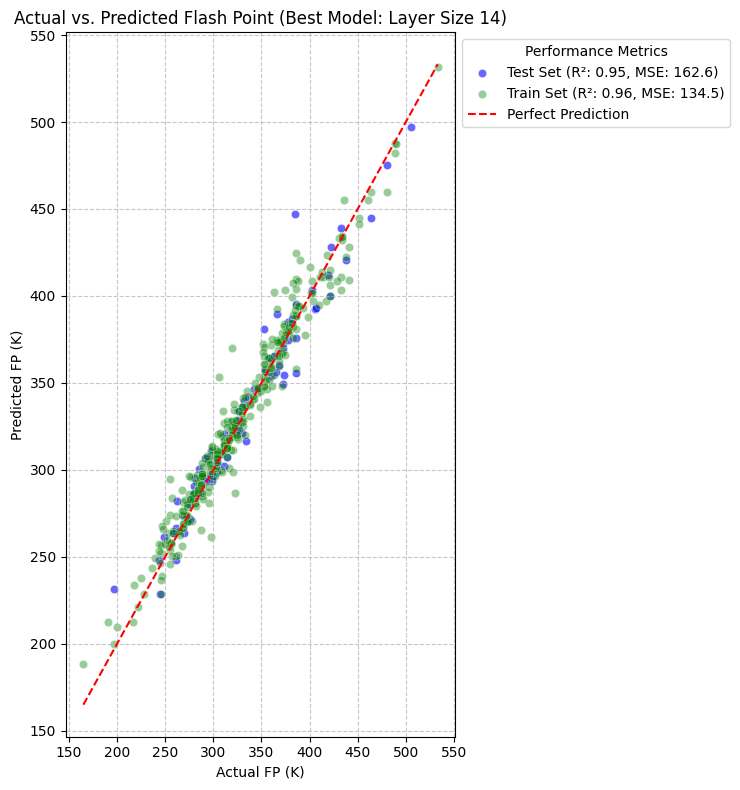

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# Re-run the train-test split for the best run to get the correct data
# Use the X and y from FP_df2, which are the currently active X and y
# Use the best_run_random_state from the latest model training (cell fSvURxYpTbaG)

X_train_best_run, X_test_best_run, y_train_best_run, y_test_best_run = train_test_split(
    X, y, test_size=0.2, random_state=best_params['run'], stratify=df_train['Family']
)

# Use the best_X_scaler and best_y_scaler saved from the best run
X_train_scaled_best_run = best_X_scaler.transform(X_train_best_run)
y_train_scaled_best_run = best_y_scaler.transform(y_train_best_run)
X_test_scaled_best_run = best_X_scaler.transform(X_test_best_run)

# --- Predictions for Test Set ---
y_pred_scaled_best_test = best_model(X_test_scaled_best_run, training=False).numpy()
y_pred_best_test = best_y_scaler.inverse_transform(y_pred_scaled_best_test)

# Calculate MSE and R2 for the best model predictions (Test Set)
mse_test_best = mean_squared_error(y_test_best_run, y_pred_best_test)
r2_test_best = r2_score(y_test_best_run, y_pred_best_test)

# --- Predictions for Train Set ---
y_pred_scaled_best_train = best_model(X_train_scaled_best_run, training=False).numpy()
y_pred_best_train = best_y_scaler.inverse_transform(y_pred_scaled_best_train)

# Calculate MSE and R2 for the best model predictions (Train Set)
mse_train_best = mean_squared_error(y_train_best_run, y_pred_best_train)
r2_train_best = r2_score(y_train_best_run, y_pred_best_train)

# Prepare data for plotting
y_out_test = pd.DataFrame({
    'Actual': y_test_best_run.flatten(),
    'Predicted': y_pred_best_test.flatten()
})

y_out_train = pd.DataFrame({
    'Actual': y_train_best_run.flatten(),
    'Predicted': y_pred_best_train.flatten()
})

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 8)) # Increased figure size for better readability

# Plot Test Set data
sns.scatterplot(x=y_out_test['Actual'], y=y_out_test['Predicted'], alpha=0.6, color='blue',
                label=f'Test Set (R²: {r2_test_best:.2f}, MSE: {mse_test_best:.1f})')

# Plot Train Set data
sns.scatterplot(x=y_out_train['Actual'], y=y_out_train['Predicted'], alpha=0.4, color='green',
                label=f'Train Set (R²: {r2_train_best:.2f}, MSE: {mse_train_best:.1f})')

# Plot the perfect prediction line
# Determine overall min/max for the perfect prediction line to cover both train and test data ranges
min_val = np.min([y_out_test['Actual'].min(), y_out_train['Actual'].min()])
max_val = np.max([y_out_test['Actual'].max(), y_out_train['Actual'].max()])
plt.plot([min_val, max_val], [min_val, max_val], '--r', label='Perfect Prediction')

plt.title(f"Actual vs. Predicted Flash Point (Best Model: Layer Size {best_params['layer_size']})")
plt.xlabel('Actual FP (K)')
plt.ylabel('Predicted FP (K)')
plt.legend(title='Performance Metrics', loc='upper left', bbox_to_anchor=(1, 1)) # Add a title to the legend and place it outside
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 0.75, 1]) # Adjust layout to make space for the legend if outside
plt.show()

In [ ]:
best_model.save('best_flash_point_model.keras')
print("Best model saved to 'best_flash_point_model.keras'")

Best model saved to 'best_flash_point_model.keras'


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import tensorflow as tf

# Configuration
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
layer_sizes = [6, 8, 10, 12, 14, 16, 18]

# Storage for detailed results
detailed_results = []
best_mse_overall = float('inf')
best_model_cv = None
best_X_scaler_cv = None
best_y_scaler_cv = None
best_params_cv = None

for layer_size in layer_sizes:
    print(f"--- Testing Layer Size: {layer_size} ---")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, df_train['Family'])):
        # Split data
        X_train_cv, X_val_cv = X[train_idx], X[val_idx]
        y_train_cv, y_val_cv = y[train_idx], y[val_idx]

        # Scalers
        X_scaler = StandardScaler()
        y_scaler = StandardScaler()

        X_train_scaled = X_scaler.fit_transform(X_train_cv)
        y_train_scaled = y_scaler.fit_transform(y_train_cv)
        X_val_scaled = X_scaler.transform(X_val_cv)

        # Model Definition
        model = Sequential([
            Input(shape=(X_train_scaled.shape[1],)),
            Dense(layer_size, activation='sigmoid'),
            Dense(1, activation='linear')
        ])

        model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

        # Training
        model.fit(X_train_scaled, y_train_scaled, epochs=300, batch_size=64, verbose=0)

        # Train Predictions
        y_train_pred_scaled = model.predict(X_train_scaled, verbose=0)
        y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)
        mse_train = mean_squared_error(y_train_cv, y_train_pred)
        r2_train = r2_score(y_train_cv, y_train_pred)

        # Validation Predictions
        y_val_pred_scaled = model.predict(X_val_scaled, verbose=0)
        y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled)
        mse_val = mean_squared_error(y_val_cv, y_val_pred)
        r2_val = r2_score(y_val_cv, y_val_pred)

        # Store individual fold metrics
        detailed_results.append({
            'layer_size': layer_size,
            'fold': fold + 1,
            'mse_train': mse_train,
            'r2_train': r2_train,
            'mse_val': mse_val,
            'r2_val': r2_val
        })

        # Track best model based on validation MSE
        if mse_val < best_mse_overall:
            best_mse_overall = mse_val
            best_params_cv = {'layer_size': layer_size, 'fold': fold + 1}
            best_model_cv = model
            best_X_scaler_cv = X_scaler
            best_y_scaler_cv = y_scaler

detailed_cv_results_df = pd.DataFrame(detailed_results)
print("\nDetailed Cross-Validation Results:")
display(detailed_cv_results_df)

--- Testing Layer Size: 6 ---
--- Testing Layer Size: 8 ---
--- Testing Layer Size: 10 ---
--- Testing Layer Size: 12 ---
--- Testing Layer Size: 14 ---
--- Testing Layer Size: 16 ---
--- Testing Layer Size: 18 ---

Detailed Cross-Validation Results:


,layer_size,fold,mse_train,r2_train,mse_val,r2_val
0,6,1,146.716797,0.954520,506.645203,0.868598
1,6,2,126.252366,0.961297,312.173875,0.908799
2,6,3,148.578227,0.955034,378.115819,0.879987
3,6,4,139.377401,0.957914,188.437103,0.938673
4,6,5,174.569604,0.948140,187.914840,0.927714
...,...,...,...,...,...,...
65,18,6,77.473886,0.976510,204.074486,0.935754
66,18,7,80.659417,0.975839,293.710603,0.896755
67,18,8,79.894260,0.974886,434.894761,0.895976
68,18,9,91.716263,0.972350,202.450205,0.933251


In [ ]:
# Resumen estadístico de la validación cruzada detallada
cv_summary_df = detailed_cv_results_df.groupby('layer_size').agg({
    'mse_train': ['mean', 'std'],
    'r2_train': ['mean', 'std'],
    'mse_val': ['mean', 'std'],
    'r2_val': ['mean', 'std']
}).round(4)

print("Resumen Estadístico por Tamaño de Capa:")
display(cv_summary_df)

# Mostrar los mejores 5 pliegues individuales basados en MSE de validación
print("\nTop 5 pliegues individuales con menor error de validación:")
display(detailed_cv_results_df.nsmallest(5, 'mse_val'))

Resumen Estadístico por Tamaño de Capa:


mse_train          r2_train           mse_val            r2_val  \
                mean      std     mean     std      mean       std    mean   
layer_size                                                                   
6           142.2463  13.3779   0.9568  0.0037  326.9608  119.4911  0.9010   
8           119.3940  17.2286   0.9637  0.0050  397.2489  184.0050  0.8818   
10          108.7961   8.8239   0.9669  0.0025  298.6608   88.6623  0.9087   
12           93.6287   5.4065   0.9715  0.0020  280.1499   92.3603  0.9146   
14           87.6631   7.8267   0.9733  0.0025  348.8069  138.7305  0.8949   
16           87.5470   6.6433   0.9734  0.0020  308.0386  130.0885  0.9078   
18           83.9768   5.3802   0.9745  0.0015  292.2564  125.7650  0.9123   

                    
               std  
layer_size          
6           0.0295  
8           0.0437  
10          0.0241  
12          0.0233  
14          0.0347  
16          0.0313  
18          0.0312


Top 5 pliegues individuales con menor error de validación:


,layer_size,fold,mse_train,r2_train,mse_val,r2_val
63,18,4,88.024007,0.973421,112.371241,0.963429
54,16,5,93.312701,0.972279,117.670008,0.954735
34,12,5,93.749424,0.972149,120.182326,0.953769
44,14,5,91.323804,0.972870,133.166089,0.948774
64,18,5,89.596824,0.973383,136.347457,0.947550


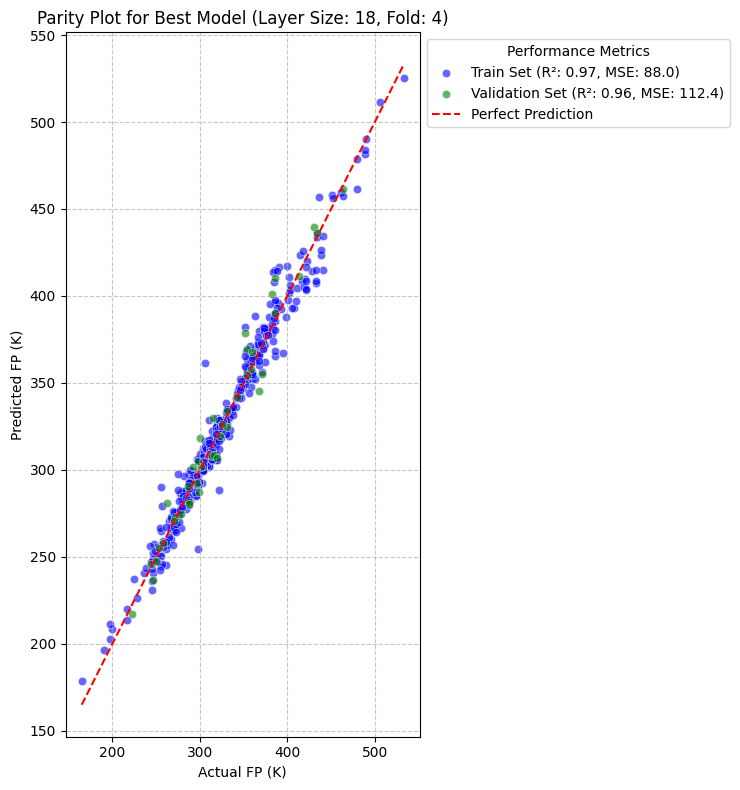

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score

# Re-perform the split for the best fold using StratifiedKFold
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42) # Consistent random_state with training

best_fold_index = best_params_cv['fold'] - 1 # Adjust to 0-based index

for fold, (train_idx, val_idx) in enumerate(skf.split(X, df_train['Family'])):
    if fold == best_fold_index:
        X_train_best_cv, X_val_best_cv = X[train_idx], X[val_idx]
        y_train_best_cv, y_val_best_cv = y[train_idx], y[val_idx]
        break

# Scale the data using the best scalers
X_train_scaled_best_cv = best_X_scaler_cv.transform(X_train_best_cv)
X_val_scaled_best_cv = best_X_scaler_cv.transform(X_val_best_cv)

# Make predictions with the best model
y_train_pred_scaled_best_cv = best_model_cv.predict(X_train_scaled_best_cv, verbose=0)
y_val_pred_scaled_best_cv = best_model_cv.predict(X_val_scaled_best_cv, verbose=0)

# Inverse transform predictions to original scale
y_train_pred_best_cv = best_y_scaler_cv.inverse_transform(y_train_pred_scaled_best_cv).flatten()
y_val_pred_best_cv = best_y_scaler_cv.inverse_transform(y_val_pred_scaled_best_cv).flatten()

# Calculate metrics for labels
mse_train_best_cv = mean_squared_error(y_train_best_cv, y_train_pred_best_cv)
r2_train_best_cv = r2_score(y_train_best_cv, y_train_pred_best_cv)

mse_val_best_cv = mean_squared_error(y_val_best_cv, y_val_pred_best_cv)
r2_val_best_cv = r2_score(y_val_best_cv, y_val_pred_best_cv)

# Create the parity plot
plt.figure(figsize=(10, 8))

# Plot Train Set data
sns.scatterplot(x=y_train_best_cv.flatten(), y=y_train_pred_best_cv, alpha=0.6, color='blue',
                label=f'Train Set (R\u00b2: {r2_train_best_cv:.2f}, MSE: {mse_train_best_cv:.1f})')

# Plot Validation Set data
sns.scatterplot(x=y_val_best_cv.flatten(), y=y_val_pred_best_cv, alpha=0.6, color='green',
                label=f'Validation Set (R\u00b2: {r2_val_best_cv:.2f}, MSE: {mse_val_best_cv:.1f})')

# Plot the perfect prediction line
min_val = min(y_train_best_cv.min(), y_val_best_cv.min(), y_train_pred_best_cv.min(), y_val_pred_best_cv.min())
max_val = max(y_train_best_cv.max(), y_val_best_cv.max(), y_train_pred_best_cv.max(), y_val_pred_best_cv.max())

plt.plot([min_val, max_val], [min_val, max_val], '--r', label='Perfect Prediction')

plt.title(f"Parity Plot for Best Model (Layer Size: {best_params_cv['layer_size']}, Fold: {best_params_cv['fold']})")
plt.xlabel('Actual FP (K)')
plt.ylabel('Predicted FP (K)')
plt.legend(title='Performance Metrics', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 0.75, 1]) # Adjust layout to make space for the legend
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd

# Re-create the StratifiedKFold split to get the indices for the best fold
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42) # Use the same random_state as the CV training

best_fold_index = best_params_cv['fold'] - 1 # Adjust to 0-based index

# Iterate through the folds to find the indices of the best fold
train_idx_best_fold = None
val_idx_best_fold = None
for fold, (train_idx, val_idx) in enumerate(skf.split(X, df_train['Family'])):
    if fold == best_fold_index:
        train_idx_best_fold = train_idx
        val_idx_best_fold = val_idx
        break

# Ensure indices were found
if train_idx_best_fold is None or val_idx_best_fold is None:
    raise ValueError(f"Could not find indices for best fold {best_params_cv['fold']}")

# --- Prepare DataFrame for Train Set of the Best Fold ---
df_train_results_cv = df_train.iloc[train_idx_best_fold].copy() # Use iloc with integer indices
df_train_results_cv['Actual_Flash_Point_K'] = y_train_best_cv.flatten()
df_train_results_cv['Predicted_Flash_Point_K'] = y_train_pred_best_cv.flatten()
df_train_results_cv['Dataset_Type'] = 'Train Set'

# --- Prepare DataFrame for Validation Set of the Best Fold ---
df_val_results_cv = df_train.iloc[val_idx_best_fold].copy() # Use iloc with integer indices
df_val_results_cv['Actual_Flash_Point_K'] = y_val_best_cv.flatten()
df_val_results_cv['Predicted_Flash_Point_K'] = y_val_pred_best_cv.flatten()
df_val_results_cv['Dataset_Type'] = 'Validation Set'

# Concatenate both DataFrames and reset the index to ensure uniqueness
combined_results_df_StratifiedKFold = pd.concat([df_train_results_cv, df_val_results_cv]).reset_index(drop=True)
combined_results_df_StratifiedKFold.to_csv('combined_results_df_StratifiedKFold.csv', index=False)

print("Combined results DataFrame 'combined_results_df_StratifiedKFold' created.")

Combined results DataFrame 'combined_results_df_StratifiedKFold' created.


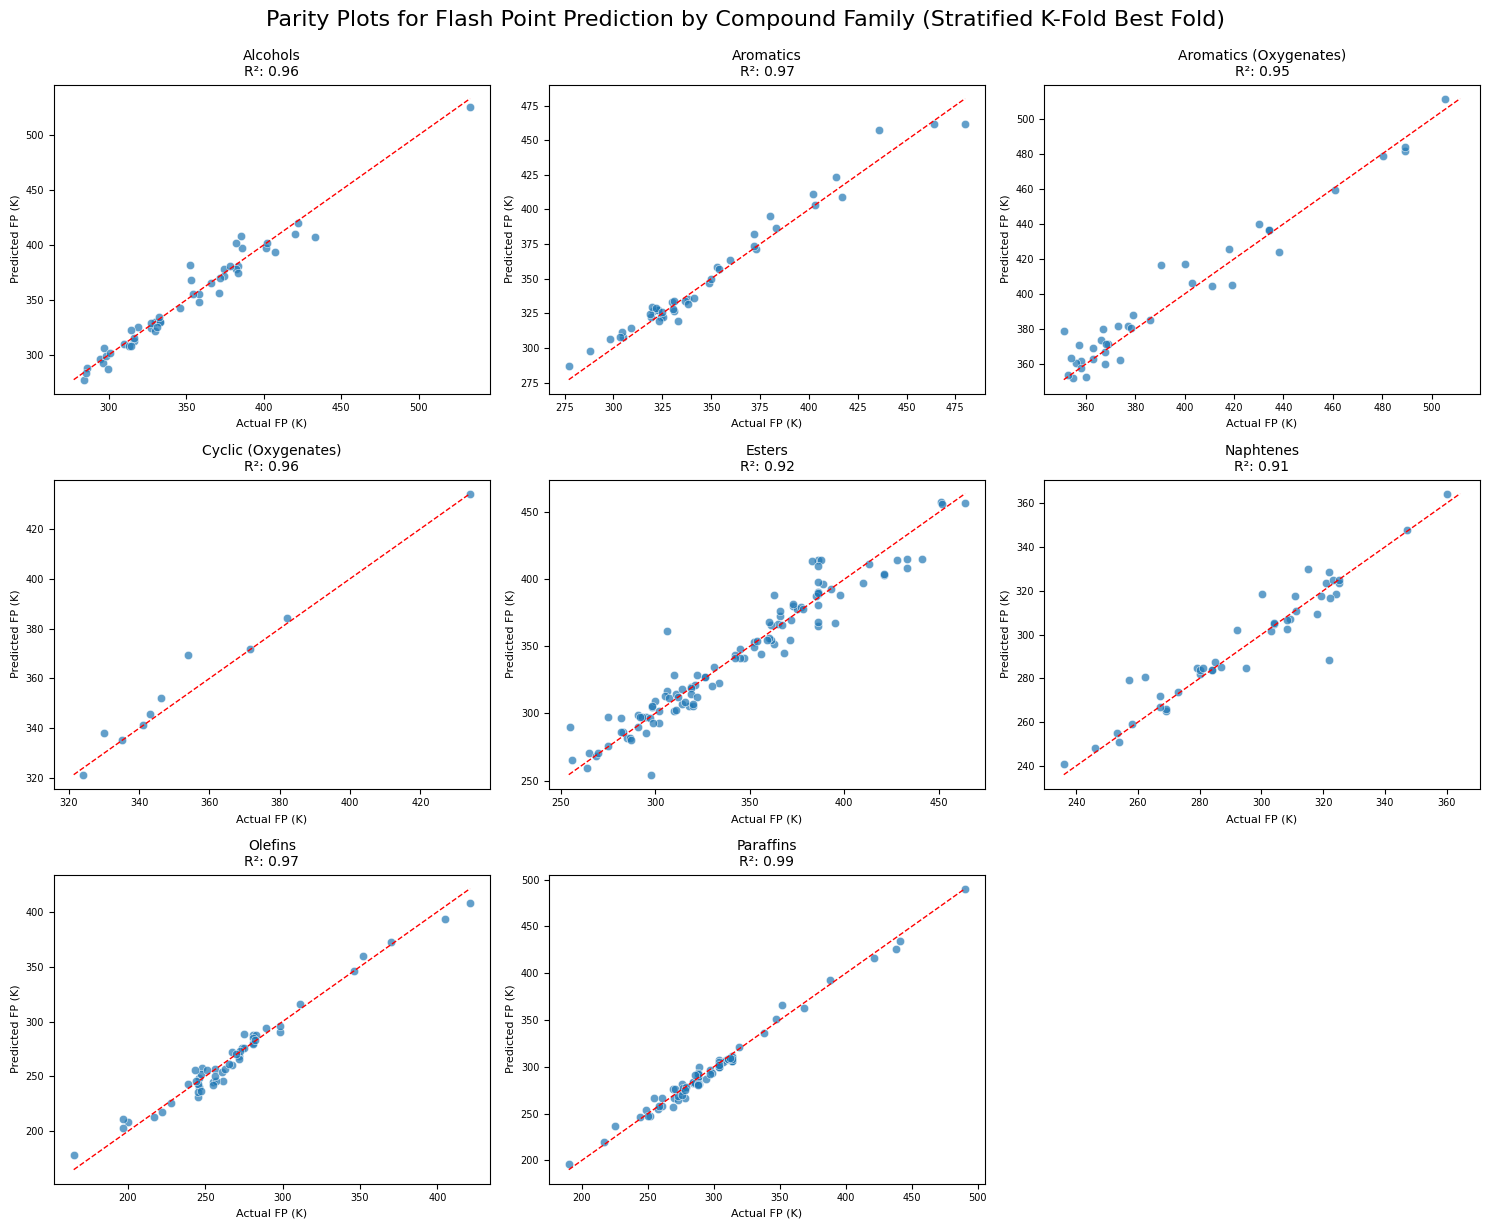

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import numpy as np

# Get unique families from the combined_results_df_StratifiedKFold DataFrame
unique_families_skf = combined_results_df_StratifiedKFold['Family'].unique()

num_families_skf = len(unique_families_skf)
num_cols_skf = 3 # Number of columns in the grid
num_rows_skf = (num_families_skf + num_cols_skf - 1) // num_cols_skf # Calculate number of rows needed

plt.figure(figsize=(num_cols_skf * 5, num_rows_skf * 4)) # Adjust figure size as needed

for i, family in enumerate(unique_families_skf):
    ax = plt.subplot(num_rows_skf, num_cols_skf, i + 1)

    # Filter combined results for the current family
    family_data_skf = combined_results_df_StratifiedKFold[combined_results_df_StratifiedKFold['Family'] == family]

    # Calculate R2 for the current family
    if len(family_data_skf) > 1:
        r2_family_skf = r2_score(family_data_skf['Actual_Flash_Point_K'], family_data_skf['Predicted_Flash_Point_K'])
    else:
        r2_family_skf = np.nan # Cannot calculate R2 with less than 2 samples

    # Create scatter plot for the family
    sns.scatterplot(x='Actual_Flash_Point_K', y='Predicted_Flash_Point_K', data=family_data_skf, ax=ax, alpha=0.7)

    # Plot perfect prediction line
    min_val_skf = family_data_skf[['Actual_Flash_Point_K', 'Predicted_Flash_Point_K']].min().min()
    max_val_skf = family_data_skf[['Actual_Flash_Point_K', 'Predicted_Flash_Point_K']].max().max()
    ax.plot([min_val_skf, max_val_skf], [min_val_skf, max_val_skf], '--r', linewidth=1)

    # Set title with R2 value
    title_str_skf = f"{family}\nR²: {r2_family_skf:.2f}"
    ax.set_title(title_str_skf, fontsize=10)
    ax.set_xlabel('Actual FP (K)', fontsize=8)
    ax.set_ylabel('Predicted FP (K)', fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=7)

plt.tight_layout()
plt.suptitle('Parity Plots for Flash Point Prediction by Compound Family (Stratified K-Fold Best Fold)', y=1.02, fontsize=16)
plt.savefig('multipanel_parity_plots_by_family_stratified_kfold.png')
plt.show()

In [ ]:
import joblib

# Save the best Keras model
best_model_cv.save('best_model_stratified_kfold.keras')
print("Best Keras model saved as 'best_model_stratified_kfold.keras'")

# Save the X_scaler
joblib.dump(best_X_scaler_cv, 'best_X_scaler_stratified_kfold.pkl')
print("Best X_scaler saved as 'best_X_scaler_stratified_kfold.pkl'")

# Save the y_scaler
joblib.dump(best_y_scaler_cv, 'best_y_scaler_stratified_kfold.pkl')
print("Best y_scaler saved as 'best_y_scaler_stratified_kfold.pkl'")

Best Keras model saved as 'best_model_stratified_kfold.keras'
Best X_scaler saved as 'best_X_scaler_stratified_kfold.pkl'
Best y_scaler saved as 'best_y_scaler_stratified_kfold.pkl'


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

# Define feature columns (fg_cols) and target column
fg_cols = ['dnAB', 'dnCCDB2', 'dnQC', 'g-CH3', 'g-CH2-(linear)', 'g-O-(ring)', 'g>C=Oring', 'g-COO-(linear) ester', 'g-CH- (linear)', 'g-CH=(lineal)', 'g-CH= (ring)', 'g-CH- (ring)', 'g-CH2-(ring)', 'dnOHprim', 'dnOHsec', 'dnOHter']
target_col = 'FP Exp.2'

# --- Load the best model and scalers (assuming they are already in memory or saved) ---
# If not in memory, uncomment the lines below to load from disk:
# best_model_cv = tf.keras.models.load_model('best_model_stratified_kfold.keras')
# best_X_scaler_cv = joblib.load('best_X_scaler_stratified_kfold.pkl')
# best_y_scaler_cv = joblib.load('best_y_scaler_stratified_kfold.pkl')

# ==================================================================
#               Predictions and Metrics for FP_validation.csv
# ==================================================================
print("\n--- Processing FP_validation.csv ---")
# 1. Load the validation dataset
df_val = pd.read_csv('FP_validation.csv')

# 2. Prepare features (X) and target (y)
X_val = df_val[fg_cols + ['Modularity']].values
y_val_actual = df_val[target_col].values.reshape(-1, 1) # Reshape for scaler

# 3. Scale features using the fitted X_scaler from the best run
X_val_scaled = best_X_scaler_cv.transform(X_val)

# 4. Make predictions
y_val_pred_scaled = best_model_cv.predict(X_val_scaled, verbose=0)
y_val_pred = best_y_scaler_cv.inverse_transform(y_val_pred_scaled).flatten()

# 5. Calculate Metrics
r2_val = r2_score(y_val_actual, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val_actual, y_val_pred))
mae_val = mean_absolute_error(y_val_actual, y_val_pred)
mape_val = np.mean(np.abs((y_val_actual.flatten() - y_val_pred) / y_val_actual.flatten())) * 100

# 6. Create Comparison Table
val_results = pd.DataFrame({
    'Metric': ['R\u00b2', 'RMSE (K)', 'MAE (K)', 'MAPE (%)'],
    'Validation Set Results': [f'{r2_val:.4f}', f'{rmse_val:.2f}', f'{mae_val:.2f}', f'{mape_val:.2f}']
})

print("\nValidation Metrics Results:")
display(val_results)

# Save validation predictions to CSV
df_val['Predicted_FP'] = y_val_pred
df_val.to_csv('validation_predictions_stratified_kfold.csv', index=False)
print("Validation predictions saved to 'validation_predictions_stratified_kfold.csv'.")

# ==================================================================
#                 Predictions and Metrics for FP_test.csv
# ==================================================================
print("\n--- Processing FP_test.csv ---")
# 1. Load the test dataset
df_test_external = pd.read_csv('FP_test.csv')

# 2. Prepare features (X) and target (y)
X_test_ext = df_test_external[fg_cols + ['Modularity']].values
y_test_ext_actual = df_test_external[target_col].values.reshape(-1, 1) # Reshape for scaler

# 3. Scale features using the fitted X_scaler from the best run
X_test_ext_scaled = best_X_scaler_cv.transform(X_test_ext)

# 4. Make predictions
y_test_ext_pred_scaled = best_model_cv.predict(X_test_ext_scaled, verbose=0)
y_test_ext_pred = best_y_scaler_cv.inverse_transform(y_test_ext_pred_scaled).flatten()

# 5. Calculate Metrics
r2_test_ext = r2_score(y_test_ext_actual, y_test_ext_pred)
rmse_test_ext = np.sqrt(mean_squared_error(y_test_ext_actual, y_test_ext_pred))
mae_test_ext = mean_absolute_error(y_test_ext_actual, y_test_ext_pred)
mape_test_ext = np.mean(np.abs((y_test_ext_actual.flatten() - y_test_ext_pred) / y_test_ext_actual.flatten())) * 100

# 6. Create results table
test_ext_results = pd.DataFrame({
    'Metric': ['R\u00b2', 'RMSE (K)', 'MAE (K)', 'MAPE (%)'],
    'Test Set Results': [f'{r2_test_ext:.4f}', f'{rmse_test_ext:.2f}', f'{mae_test_ext:.2f}', f'{mape_test_ext:.2f}']
})

print("\nTest Set (External) Metrics Results:")
display(test_ext_results)

# Save test predictions to CSV
df_test_external['Predicted_FP'] = y_test_ext_pred
df_test_external.to_csv('test_file_predictions_stratified_kfold.csv', index=False)
print("Test file predictions saved to 'test_file_predictions_stratified_kfold.csv'.")


--- Processing FP_validation.csv ---

Validation Metrics Results:


,Metric,Validation Set Results
0,R²,0.9381
1,RMSE (K),13.22
2,MAE (K),8.61
3,MAPE (%),2.54


Validation predictions saved to 'validation_predictions_stratified_kfold.csv'.

--- Processing FP_test.csv ---

Test Set (External) Metrics Results:


,Metric,Test Set Results
0,R²,0.9451
1,RMSE (K),13.10
2,MAE (K),9.47
3,MAPE (%),2.82


Test file predictions saved to 'test_file_predictions_stratified_kfold.csv'.


In [ ]:
import pandas as pd

# Extract metrics from validation results
val_r2 = float(val_results.loc[val_results['Metric'] == 'R\u00b2', 'Validation Set Results'].iloc[0])
val_rmse = float(val_results.loc[val_results['Metric'] == 'RMSE (K)', 'Validation Set Results'].iloc[0])
val_mae = float(val_results.loc[val_results['Metric'] == 'MAE (K)', 'Validation Set Results'].iloc[0])
val_mape = float(val_results.loc[val_results['Metric'] == 'MAPE (%)', 'Validation Set Results'].iloc[0])

# Extract metrics from external test results
test_ext_r2 = float(test_ext_results.loc[test_ext_results['Metric'] == 'R\u00b2', 'Test Set Results'].iloc[0])
test_ext_rmse = float(test_ext_results.loc[test_ext_results['Metric'] == 'RMSE (K)', 'Test Set Results'].iloc[0])
test_ext_mae = float(test_ext_results.loc[test_ext_results['Metric'] == 'MAE (K)', 'Test Set Results'].iloc[0])
test_ext_mape = float(test_ext_results.loc[test_ext_results['Metric'] == 'MAPE (%)', 'Test Set Results'].iloc[0])

# Literature results from Saldana et al. (2011)
lit_r2 = 0.944
lit_rmse = 13.2
lit_mae = 8.4
lit_mape = 2.5

# Create a consolidated comparison DataFrame
consolidated_comparison_df = pd.DataFrame({
    'Metric': ['R\u00b2', 'RMSE (K)', 'MAE (K)', 'MAPE (%)'],
    'Our Model (Validation Set)': [f'{val_r2:.4f}', f'{val_rmse:.2f}', f'{val_mae:.2f}', f'{val_mape:.2f}'],
    'Our Model (External Test Set)': [f'{test_ext_r2:.4f}', f'{test_ext_rmse:.2f}', f'{test_ext_mae:.2f}', f'{test_ext_mape:.2f}'],
    'Saldana et al. (2011)': [f'{lit_r2:.4f}', f'{lit_rmse:.2f}', f'{lit_mae:.2f}', f'{lit_mape:.2f}']
})

print("\nConsolidated Comparison of Flash Point Prediction Models:")
display(consolidated_comparison_df)


Consolidated Comparison of Flash Point Prediction Models:


,Metric,Our Model (Validation Set),Our Model (External Test Set),Saldana et al. (2011)
0,R²,0.9381,0.9451,0.9440
1,RMSE (K),13.22,13.10,13.20
2,MAE (K),8.61,9.47,8.40
3,MAPE (%),2.54,2.82,2.50
